# **Margin Trading (Margin-Handel) & Levered Returns(gehebelte Renditen)**

Definition: "Margin trading refers to the practice of using **borrowed funds** from a broker to trade a financial asset, wich forms the collateral for the loan from the broker." (Investopedia.com)

In simple words: Investors **don´t pay the full price** but they get the full benefit (less borrowing costs)

It´s a two edged sword: Leverage **amplifies both gains and losses.**
In the event of a loss, the collateral gets reduced and the investor either posts additional margin or the brokers closes the position.

**Example**

A Trader buys a stock (stock price:100) **on margin (50%).** After one day the price increases to 110. Calculate **unlevered return** and **levered return.**

In [516]:
import numpy as np

In [517]:
p0=100
p1=110
leverage=2
margin=p0/2

In [518]:
margin

50.0

In [519]:
unlev_return=(p1-p0)/p0 # simple return
unlev_return

0.1

In [520]:
lev_return=(p1-p0)/margin # simple return
lev_return

0.2

In [521]:
lev_return==unlev_return*leverage

True

In [522]:
unlev_return=np.log((p1-p0)/p0+1) # Log return
unlev_return

np.float64(0.09531017980432493)

In [523]:
lev_return=np.log((p1-p0)/p0+margin) # Log return
lev_return

np.float64(3.914021008090819)

In [524]:
lev_return==unlev_return*leverage # this relationship does not hold for Log returns...

np.False_

# Part 2: Levered Returns (gehebelte Renditen)

**Hypothesis: For (highly) profitable Investment: The more Leverage the better?**

In [525]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fast')
plt.style.available
pd.options.display.float_format='{:.5f}'.format
# pd.set_option('display.max_rows', 10)

In [526]:
msft = pd.read_csv(r"C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Data\msft.csv", index_col = "Date", parse_dates = ["Date"])
msft

,Price,Returns
Date,,
2014-10-01,38.88016,NaN
2014-10-02,38.76157,-0.00305
2014-10-03,39.04110,0.00721
2014-10-06,39.04110,0.00000
2014-10-07,38.56676,-0.01215
...,...,...
2021-05-24,241.74454,0.02288
2021-05-25,242.65067,0.00375
2021-05-26,242.42894,-0.00091


In [527]:
msft['Simple_Returns']=msft.Price.pct_change() # Simple Returns of percentage change

In [528]:
leverage=3
leverageI=8.5

(Simplified) Assumptions:
- Restore leverage on a daily basis (by buying/selling shares)
- no trading costs
- no borrowing costs

In [529]:
msft['Leverage_Returns']=msft.Simple_Returns.mul(leverage)
msft['Limit_Loss_100%']=msft.Simple_Returns.mul(leverageI)
msft

,Price,Returns,Simple_Returns,Leverage_Returns,Limit_Loss_100%
Date,,,,,
2014-10-01,38.88016,NaN,NaN,NaN,NaN
2014-10-02,38.76157,-0.00305,-0.00305,-0.00915,-0.02593
2014-10-03,39.04110,0.00721,0.00721,0.02163,0.06130
2014-10-06,39.04110,0.00000,0.00000,0.00000,0.00000
2014-10-07,38.56676,-0.01215,-0.01215,-0.03645,-0.10327
...,...,...,...,...,...
2021-05-24,241.74454,0.02288,0.02288,0.06865,0.19450
2021-05-25,242.65067,0.00375,0.00375,0.01124,0.03186
2021-05-26,242.42894,-0.00091,-0.00091,-0.00274,-0.00777


In [530]:
msft['Leverage_Returns']=np.where(msft['Leverage_Returns']<-1,-1,msft['Leverage_Returns']) # Limit Loss to 100%
msft['Limit_Loss_100%']=np.where(msft['Limit_Loss_100%']<-1,-1,msft['Limit_Loss_100%']) # Limit Loss to 100%

In [531]:
msft

,Price,Returns,Simple_Returns,Leverage_Returns,Limit_Loss_100%
Date,,,,,
2014-10-01,38.88016,NaN,NaN,NaN,NaN
2014-10-02,38.76157,-0.00305,-0.00305,-0.00915,-0.02593
2014-10-03,39.04110,0.00721,0.00721,0.02163,0.06130
2014-10-06,39.04110,0.00000,0.00000,0.00000,0.00000
2014-10-07,38.56676,-0.01215,-0.01215,-0.03645,-0.10327
...,...,...,...,...,...
2021-05-24,241.74454,0.02288,0.02288,0.06865,0.19450
2021-05-25,242.65067,0.00375,0.00375,0.01124,0.03186
2021-05-26,242.42894,-0.00091,-0.00091,-0.00274,-0.00777


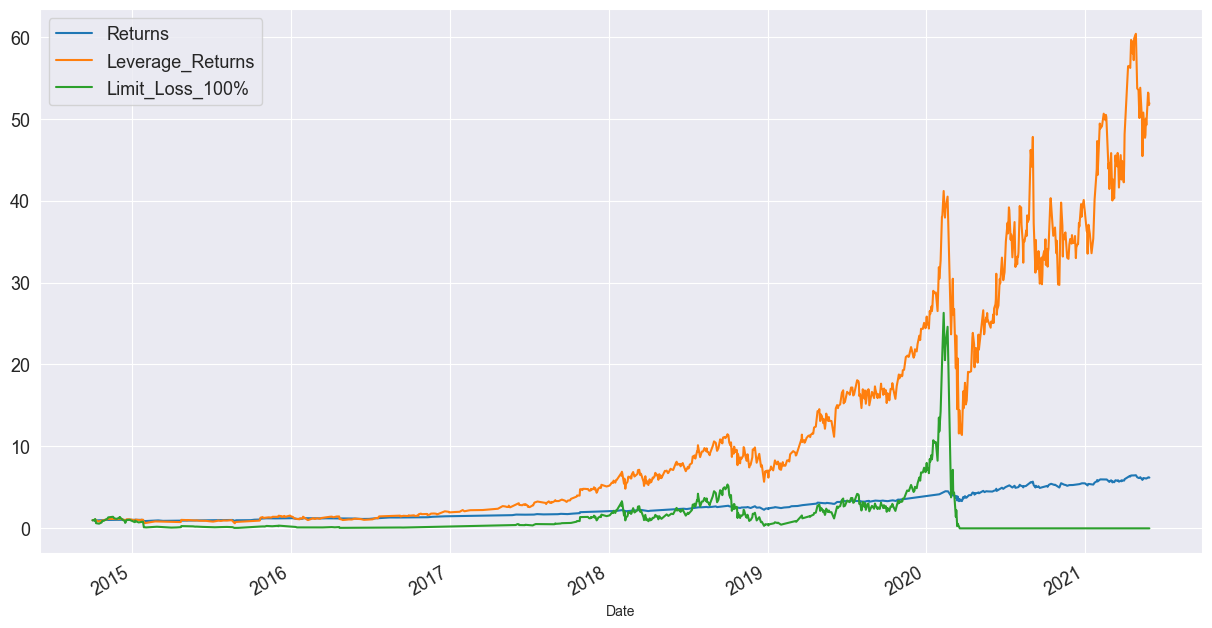

In [532]:
# msft[['Returns','Leverage_Returns']].add(1).cumprod().plot(figsize=(15,8),fontsize=13)
msft[['Returns','Leverage_Returns','Limit_Loss_100%']].add(1).cumprod().plot(figsize=(15,8),fontsize=13)
plt.legend(fontsize=13)
plt.show()

In [533]:
msft.Simple_Returns.max()

np.float64(0.1421688935378802)

In [534]:
msft.Leverage_Returns.max()

np.float64(0.4265066806136406)

In [535]:
msft.Simple_Returns.min()

np.float64(-0.14739068513674658)

In [536]:
msft.Leverage_Returns.min()

np.float64(-0.44217205541023974)

**What happens when Leverage greater than...?**

In [537]:
-1/msft.Simple_Returns.min()

np.float64(6.784689270371577)

**Take Home:**
 1.) With Leverage yo ucan (theoretically) **loser more than the initial Margin** (in practice: margin call / margin closeout before)
 2.) Even for (highly) profitable instruments: **"The more leverage the better" does not hold.**
 3.) It´s a two edged **(non-symmetrical)** sword: **Leverage amplifies losses more than it amplifies gains**